In [1]:
# Swap in an Ornstein–Uhlenbeck (OU / exponential) kernel and re-run the demo
# k(x, x') = variance * exp(-|x - x'| / length_scale)
import numpy as np
import matplotlib.pyplot as plt

### A toy model of OU process

In [ ]:
rng = np.random.default_rng(123)

def ou_kernel(xa, xb, length_scale=0.25, variance=1.0):
    xa = np.atleast_2d(xa).reshape(-1, 1)  # (n_a, 1)
    xb = np.atleast_2d(xb).reshape(1, -1)  # (1, n_b)
    d = np.abs(xa - xb)                    # pairwise distances
    return variance * np.exp(-d / length_scale)

def gp_prior_sample(X, n_samples=5, kernel=ou_kernel, **kargs):
    K = kernel(X, X, **kargs)
    K = K + 1e-9*np.eye(len(X))
    L = np.linalg.cholesky(K)
    z = rng.standard_normal((len(X), n_samples))
    return (L @ z).T


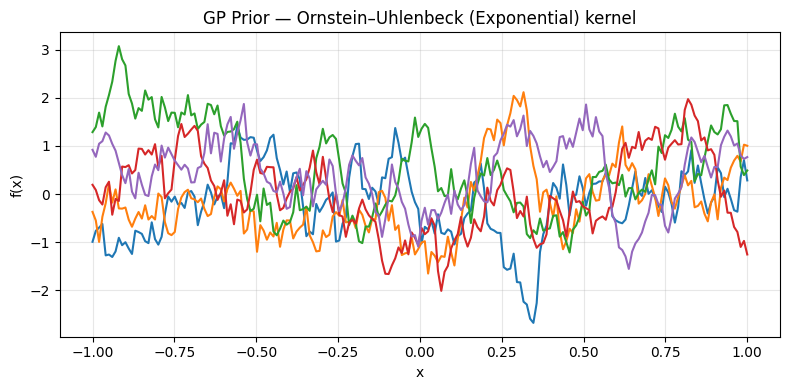

In [3]:
# Parameters
X_plot = np.linspace(-1.0, 1.0, 200)
ell = 0.2         # OU length-scale
var = 1.0
noise_std = 0.05

# 1) Prior samples (OU)
prior_samples = gp_prior_sample(X_plot, n_samples=5, kernel=ou_kernel, length_scale=ell, variance=var)
plt.figure(figsize=(8, 4))
for f in prior_samples:
    plt.plot(X_plot, f, lw=1.5)
plt.title("GP Prior — Ornstein–Uhlenbeck (Exponential) kernel")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### Does OU process keep the geometric structure of the data?